In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from datetime import datetime , timedelta 
from pandas.plotting import register_matplotlib_converters
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from time import time

In [2]:
register_matplotlib_converters()

In [3]:
def parser(s):
    return datetime.strptime(s,"%Y-%m-%d")


In [ ]:

production_ice_cream = pd.read_csv("ice_cream",parse_dates=[0],index_col=0,date_parser=parser)
production_ice_cream.head()

C:\Users\rt\AppData\Local\Temp\ipykernel_13280\2963293451.py:3: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  production_ice_cream = pd.read_csv("ice_cream",parse_dates=[0],index_col=0,date_parser=parser)


,IPN31152N
DATE,
1972-01-01,59.9622
1972-02-01,67.0605
1972-03-01,74.2350
1972-04-01,78.1120
1972-05-01,84.7636


In [5]:
production_ice_cream=production_ice_cream.rename(columns={"IPN31152N":"PRODUCTION"})
production_ice_cream.head()

,PRODUCTION
DATE,
1972-01-01,59.9622
1972-02-01,67.0605
1972-03-01,74.2350
1972-04-01,78.1120
1972-05-01,84.7636


In [6]:
production_ice_cream.index = pd.to_datetime(production_ice_cream.index)
production_ice_cream.index[:5]  

DatetimeIndex(['1972-01-01', '1972-02-01', '1972-03-01', '1972-04-01',
               '1972-05-01'],
              dtype='datetime64[ns]', name='DATE', freq=None)

In [7]:
production_ice_cream=production_ice_cream.asfreq(pd.infer_freq(production_ice_cream.index))
production_ice_cream.head()

,PRODUCTION
DATE,
1972-01-01,59.9622
1972-02-01,67.0605
1972-03-01,74.2350
1972-04-01,78.1120
1972-05-01,84.7636


In [8]:
start_date=pd.to_datetime("2010-01-01")
production_ice_cream=production_ice_cream[start_date:]

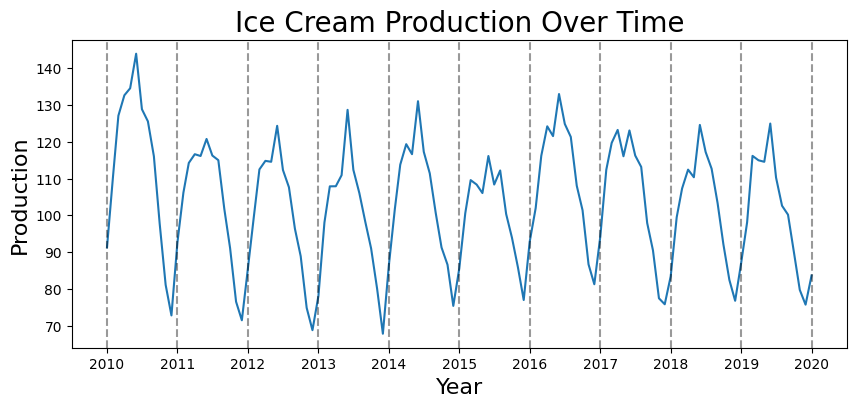

In [9]:
plt.figure(figsize=(10,4))
plt.plot(production_ice_cream)
plt.title("Ice Cream Production Over Time",fontsize=20)
plt.ylabel("Production",fontsize="16")
plt.xlabel("Year",fontsize=16)
for year in range(2010,2021):
    plt.axvline(pd.to_datetime(str(year)+"-01-01"),color="k",linestyle="--",alpha=0.4)

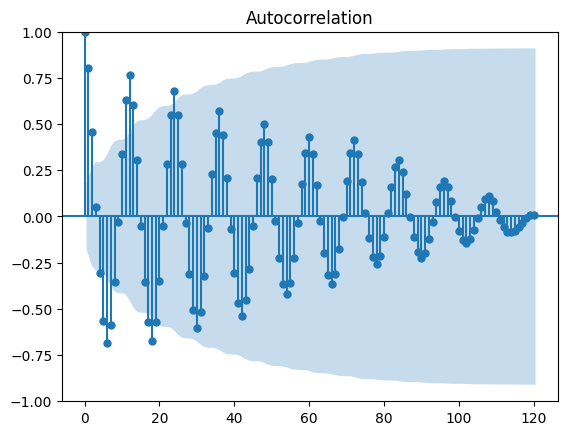

In [10]:
plot_acf(production_ice_cream,lags=len(production_ice_cream.index)-1);

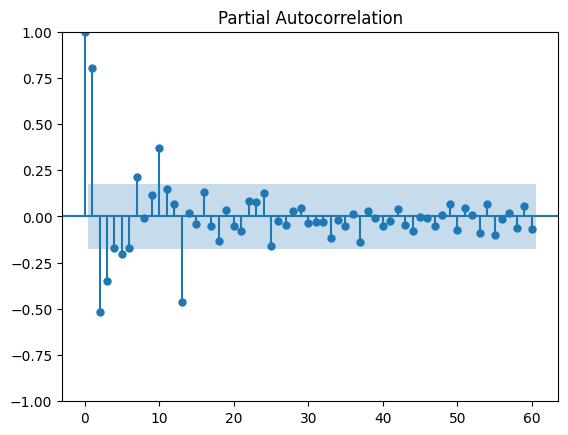

In [11]:
plot_pacf(production_ice_cream,lags=len(production_ice_cream)//2);

In [12]:
train_end=datetime(2018,12,1)
test_end=datetime(2019,12,1)

In [13]:
train_data=production_ice_cream[:train_end]
test_data=production_ice_cream[train_end+timedelta(days=1):test_end]

In [ ]:
model=ARIMA(train_data,order=(3,0,0))

In [ ]:
start= time()
model_fit=model.fit()
end=time()
print("Model Fitting Time:",end-start)

Model Fitting Time: 0.09379935264587402


In [16]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             PRODUCTION   No. Observations:                  108
Model:                 ARIMA(3, 0, 0)   Log Likelihood                -374.085
Date:                Thu, 13 Mar 2025   AIC                            758.170
Time:                        20:07:57   BIC                            771.580
Sample:                    01-01-2010   HQIC                           763.607
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        103.5743      2.169     47.761      0.000      99.324     107.825
ar.L1          1.0469      0.102     10.256      0.000       0.847       1.247
ar.L2         -0.0523      0.175     -0.298      0.7

In [ ]:
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]

In [ ]:
predictions=model_fit.predict(start=pred_start_date,end=pred_end_date)
predictions[:5]

2019-01-01     81.236249
2019-02-01     90.140510
2019-03-01    101.523172
2019-04-01    111.164049
2019-05-01    117.060582
Freq: MS, Name: predicted_mean, dtype: float64

In [19]:
residuals=test_data["PRODUCTION"]-predictions
residuals[:5]

DATE
2019-01-01     5.762551
2019-02-01     7.971090
2019-03-01    14.648628
2019-04-01     3.806251
2019-05-01    -2.499282
Freq: MS, dtype: float64

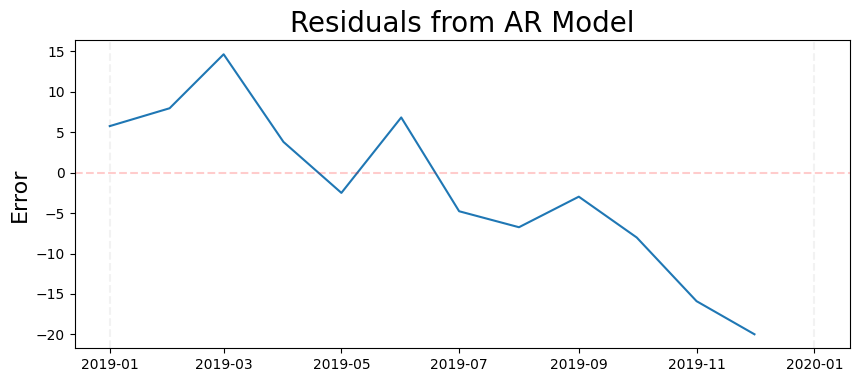

In [20]:
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("Residuals from AR Model",fontsize=20)
plt.ylabel("Error",fontsize=16)
plt.axhline(0,color="r",linestyle="--",alpha=0.2)
for year in range(2019,2021):
    plt.axvline(pd.to_datetime(str(year)+"-01-01"),color="k",linestyle="--",alpha=.05)

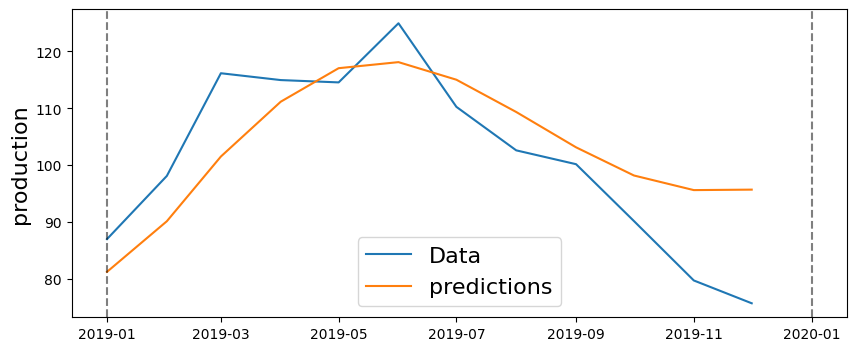

In [21]:
plt.figure(figsize=(10,4))
plt.plot(test_data)
plt.plot(predictions)
plt.legend(("Data","predictions"),fontsize="16")
plt.ylabel("production",fontsize=16)
for year in range(2019,2021):
    plt.axvline(pd.to_datetime(str(year)+"-01-01"),color="k",linestyle="--",alpha=.5)

In [22]:
print("Mean Absolute Percent Error:",round(np.mean(abs(residuals/test_data["PRODUCTION"]))),4)

Mean Absolute Percent Error: 0 4


In [23]:
print("Root Mean Squared Error:",round(np.mean(np.sqrt(residuals**2))))

Root Mean Squared Error: 8


In [ ]:
model=ARIMA(train_data,order=(7,0,0))

In [ ]:
start= time()
model_fit=model.fit()
end=time()
print("Model Fitting Time:",end-start)

Model Fitting Time: 0.23713922500610352


In [26]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             PRODUCTION   No. Observations:                  108
Model:                 ARIMA(7, 0, 0)   Log Likelihood                -361.526
Date:                Thu, 13 Mar 2025   AIC                            741.051
Time:                        20:07:58   BIC                            765.191
Sample:                    01-01-2010   HQIC                           750.839
                         - 12-01-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        103.6216      1.339     77.406      0.000     100.998     106.245
ar.L1          0.9497      0.097      9.837      0.000       0.760       1.139
ar.L2         -0.0964      0.131     -0.735      0.4

In [ ]:
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]

In [ ]:
predictions=model_fit.predict(start=pred_start_date,end=pred_end_date)
predictions[:5]

2019-01-01     82.956677
2019-02-01     91.262075
2019-03-01    102.317479
2019-04-01    111.914962
2019-05-01    119.796137
Freq: MS, Name: predicted_mean, dtype: float64

In [29]:
residuals=test_data["PRODUCTION"]-predictions
residuals[:5]

DATE
2019-01-01     4.042123
2019-02-01     6.849525
2019-03-01    13.854321
2019-04-01     3.055338
2019-05-01    -5.234837
Freq: MS, dtype: float64

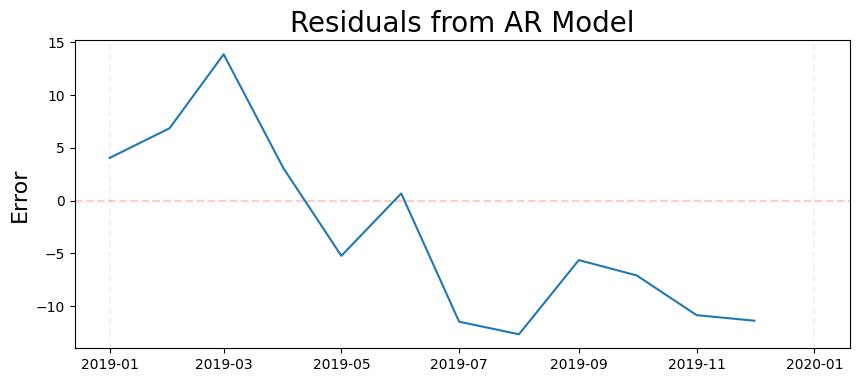

In [30]:
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("Residuals from AR Model",fontsize=20)
plt.ylabel("Error",fontsize=16)
plt.axhline(0,color="r",linestyle="--",alpha=0.2)
for year in range(2019,2021):
    plt.axvline(pd.to_datetime(str(year)+"-01-01"),color="k",linestyle="--",alpha=.05)

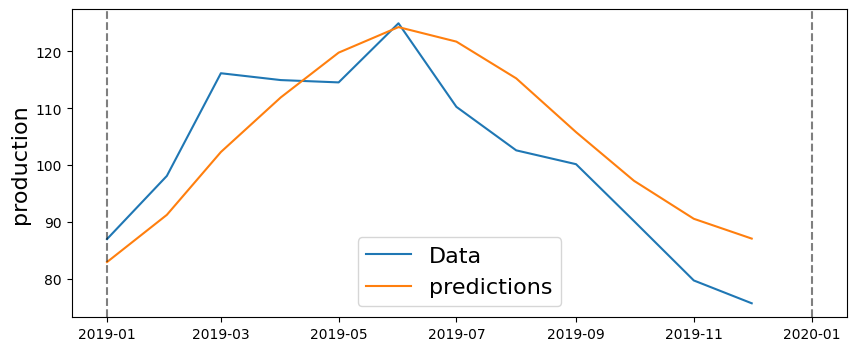

In [31]:
plt.figure(figsize=(10,4))
plt.plot(test_data)
plt.plot(predictions)
plt.legend(("Data","predictions"),fontsize="16")
plt.ylabel("production",fontsize=16)
for year in range(2019,2021):
    plt.axvline(pd.to_datetime(str(year)+"-01-01"),color="k",linestyle="--",alpha=.5)

In [32]:
print("Mean Absolute Percent Error:",round(np.mean(abs(residuals/test_data["PRODUCTION"]))),4)

Mean Absolute Percent Error: 0 4


In [33]:
print("Root Mean Squared Error:",round(np.mean(np.sqrt(residuals**2))))

Root Mean Squared Error: 8
